# LUNA16 Full-Dataset Re-training — Option B Split
**Re-train v1, v2, v3 on full LUNA16 (888 patients) with bigger test set for objective comparison.**

| Split | Subsets | Patients | Note |
|---|---|---|---|
| train | 0–6 | 623 | ~5000 patches (was 585 in v1, 1407 in v2/v3) |
| val   | 7  | 89 | unchanged role; new val patients |
| test  | 8 + 9 | 176 | **2× test set vs prior** — CI halves to ±0.008 F1 |

Three models, identical training infrastructure (same hyperparameters across all):

| Version | Backbone | Loss | Aug | TTA | Notes |
|---|---|---|---|---|---|
| v1_full | ResNet-50 | weighted CE | flip/rot/erase | ✗ | original baseline recipe |
| v2_full | ResNet-50 + CBAM | Focal (α=0.25, γ=2) | + MixUp | ✓ | full v2 recipe |
| v3_full | DenseNet-121 + **CBAM** | Focal (α=0.25, γ=2) | + MixUp | ✓ | v2 recipe with backbone swap (CBAM included this time) |


## 1 · Imports & Configuration

In [1]:
import os, sys, time, json, random, copy
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from PIL import Image

random.seed(42); np.random.seed(42); torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

PATCH_DIR  = Path("luna16_patches_full")
RUNS_DIR   = Path("luna16_runs_full"); RUNS_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["non_nodule", "nodule"]
NUM_CLASSES = 2
IMG_SIZE    = 224
BATCH_SIZE  = 64
LR_MAX      = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0

# Per-version
EPOCHS_V1 = 30
EPOCHS_V2 = 25
EPOCHS_V3 = 25
EARLY_STOP_PAT = 10   # bumped from 8 — bigger dataset has room

FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0
MIXUP_ALPHA = 0.4
MIXUP_PROB  = 0.5

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print(f"PyTorch: {torch.__version__}  Device: {device}")


PyTorch: 2.6.0+cu124  Device: cuda


## 2 · Datasets & Loaders (same for v1, v2, v3)

In [2]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(PATCH_DIR/"train", transform=train_tf)
val_ds   = datasets.ImageFolder(PATCH_DIR/"val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(PATCH_DIR/"test",  transform=eval_tf)

train_labels = [y for _, y in train_ds.samples]
counts_tr    = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
w_cls        = 1.0 / (counts_tr + 1e-8)
sampler      = WeightedRandomSampler([w_cls[l] for l in train_labels],
                                      num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=USE_AMP)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)

print(f"Train: {len(train_ds)} patches  ({dict(zip(CLASS_NAMES, counts_tr.astype(int)))})")
print(f"Val:   {len(val_ds)}   patches")
print(f"Test:  {len(test_ds)}   patches  (subsets 8+9)")


Train: 4972 patches  ({'non_nodule': np.int64(1093), 'nodule': np.int64(3879)})
Val:   585   patches
Test:  1528   patches  (subsets 8+9)


## 3 · Module Library — CBAM, Focal Loss, MixUp, TTA, Models

In [3]:
# ─── CBAM ───
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels//reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels//reduction, channels, 1, bias=False),
        )
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.mlp(self.avg(x)) + self.mlp(self.max(x))) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        return self.sig(self.conv(torch.cat([avg, mx], 1))) * x

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.sa(self.ca(x))

# ─── Models ───
class ResNet50_Plain(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_f = b.fc.in_features
        b.fc = nn.Sequential(nn.BatchNorm1d(in_f), nn.Dropout(dropout), nn.Linear(in_f, num_classes))
        self.net = b
    def forward(self, x): return self.net(x)

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.stem   = nn.Sequential(b.conv1, b.bn1, b.relu, b.maxpool)
        self.layer1, self.layer2 = b.layer1, b.layer2
        self.layer3, self.layer4 = b.layer3, b.layer4
        self.cbam   = CBAM(2048, reduction=16, kernel_size=7)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(
            nn.Flatten(), nn.BatchNorm1d(2048), nn.Dropout(dropout), nn.Linear(2048, num_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        return self.head(self.pool(self.cbam(x)))

class DenseNet121_CBAM(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        b = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.features = b.features
        self.relu     = nn.ReLU(inplace=True)
        in_f          = b.classifier.in_features   # 1024
        self.cbam     = CBAM(in_f, reduction=16, kernel_size=7)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Flatten(), nn.BatchNorm1d(in_f), nn.Dropout(dropout), nn.Linear(in_f, num_classes))
    def forward(self, x):
        x = self.relu(self.features(x))
        return self.head(self.pool(self.cbam(x)))

# ─── Focal Loss ───
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

# ─── MixUp ───
def mixup(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

print("Modules defined.")


Modules defined.


## 4 · Generic Training & Evaluation Functions

In [4]:
def compute(y_true, y_pred, y_score=None):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            roc_auc_score(y_true, y_score) if y_score is not None else None)

def full_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "precision":    float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall":       float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "specificity":  float(tn/(tn+fp)) if (tn+fp) else 0.0,
        "f1":           float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "mcc":          float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc":      float(roc_auc_score(y_true, y_score)),
        "pr_auc":       float(average_precision_score(y_true, y_score)),
        "confusion":    {"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn)},
    }

def train_one_run(model, criterion, num_epochs, run_name,
                  use_mixup=False, save_dir=None):
    """Generic training loop. Returns (history, best_ckpt_path)."""
    save_dir = Path(save_dir) if save_dir else (RUNS_DIR / run_name)
    save_dir.mkdir(exist_ok=True, parents=True)

    optimizer = optim.AdamW(model.parameters(), lr=LR_MAX/25, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR_MAX, steps_per_epoch=len(train_loader),
        epochs=num_epochs, pct_start=0.3, anneal_strategy="cos",
        div_factor=25, final_div_factor=1e4)
    scaler = GradScaler('cuda', enabled=USE_AMP)

    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc",
                                "train_f1","val_f1","val_prec","val_rec","val_auc"]}
    best_f1, early_ctr = 0.0, 0
    ckpt_path = save_dir / "best.pth"

    print(f"\n=== Training {run_name} ({num_epochs} epochs, mixup={use_mixup}) ===")
    print(f"{'Ep':>3} {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} {'VaLoss':>7} "
          f"{'VaAcc':>6} {'VaF1':>6} {'VaP':>6} {'VaR':>6} {'AUC':>6} {'LR':>8} {'s':>4}")
    print("-"*96)

    for ep in range(1, num_epochs+1):
        t0 = time.time()
        # Train
        model.train(); rl, yp, yt = 0.0, [], []
        for imgs, lbs in train_loader:
            imgs, lbs = imgs.to(device), lbs.to(device)
            use_m = use_mixup and (np.random.rand() < MIXUP_PROB)
            if use_m:
                imgs, ya, yb, lam = mixup(imgs, lbs)
            optimizer.zero_grad()
            with autocast('cuda', enabled=USE_AMP):
                out = model(imgs)
                if use_m:
                    loss = lam*criterion(out, ya) + (1-lam)*criterion(out, yb)
                else:
                    loss = criterion(out, lbs)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            rl += loss.item()*imgs.size(0)
            yp.extend(out.argmax(1).cpu().numpy())
            yt.extend((ya if use_m else lbs).cpu().numpy())
        tr_loss = rl/len(train_loader.dataset)
        tr_acc, tr_p, tr_r, tr_f1, _ = compute(yt, yp)

        # Val
        model.eval(); rl, yp, yt, ys = 0.0, [], [], []
        with torch.no_grad():
            for imgs, lbs in val_loader:
                imgs, lbs = imgs.to(device), lbs.to(device)
                with autocast('cuda', enabled=USE_AMP):
                    out = model(imgs); loss = criterion(out, lbs)
                rl += loss.item()*imgs.size(0)
                probs = torch.softmax(out.float(), dim=1)[:, 1]
                yp.extend(out.argmax(1).cpu().numpy())
                ys.extend(probs.cpu().numpy())
                yt.extend(lbs.cpu().numpy())
        va_loss = rl/len(val_loader.dataset)
        va_acc, va_p, va_r, va_f1, va_auc = compute(yt, yp, ys)

        dt = time.time()-t0
        lr = optimizer.param_groups[0]["lr"]
        for k, v in [("train_loss",tr_loss),("val_loss",va_loss),
                      ("train_acc",tr_acc),("val_acc",va_acc),
                      ("train_f1",tr_f1),("val_f1",va_f1),
                      ("val_prec",va_p),("val_rec",va_r),("val_auc",va_auc)]:
            history[k].append(v)
        print(f"{ep:>3} {tr_loss:>7.4f} {tr_acc*100:>5.1f}% {tr_f1:.4f} "
              f"{va_loss:>7.4f} {va_acc*100:>5.1f}% {va_f1:.4f} "
              f"{va_p:.4f} {va_r:.4f} {va_auc:.4f} {lr:.2e} {dt:>3.0f}s")
        if va_f1 > best_f1:
            best_f1 = va_f1; early_ctr = 0
            torch.save({"epoch": ep, "run": run_name,
                         "model_state_dict": model.state_dict(),
                         "val_f1": va_f1, "val_auc": va_auc}, ckpt_path)
            print(f"    [*] best saved  val_f1={va_f1:.4f}  val_auc={va_auc:.4f}")
        else:
            early_ctr += 1
            if early_ctr >= EARLY_STOP_PAT:
                print(f"\nEarly stop at epoch {ep}"); break

    (save_dir/"history.json").write_text(json.dumps(history, indent=2))
    return history, ckpt_path

# ─── Inference ───
@torch.no_grad()
def single_infer(model, loader):
    model.eval(); ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

@torch.no_grad()
def tta_infer(model, loader):
    model.eval(); ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        views = [imgs, torch.flip(imgs, [3]), torch.flip(imgs, [2]),
                 torch.rot90(imgs, 1, [2,3]), torch.rot90(imgs, 3, [2,3])]
        all_p = []
        for v in views:
            with autocast('cuda', enabled=USE_AMP):
                out = model(v)
            all_p.append(torch.softmax(out.float(), dim=1)[:, 1])
        probs = torch.stack(all_p).mean(0)
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

print("Helpers ready.")


Helpers ready.


## 5 · v1_full — ResNet-50 baseline (weighted CE, no MixUp, no TTA)

In [5]:
# Weighted CE loss (the v1 recipe)
cls_weights = torch.tensor(1.0 / (counts_tr / counts_tr.sum()), dtype=torch.float32).to(device)
ce_loss     = nn.CrossEntropyLoss(weight=cls_weights)

model_v1 = ResNet50_Plain(NUM_CLASSES, dropout=0.4).to(device)
print(f"v1 params: {sum(p.numel() for p in model_v1.parameters()):,}")
hist_v1, ckpt_v1 = train_one_run(model_v1, ce_loss, EPOCHS_V1, "v1_full",
                                  use_mixup=False)


v1 params: 23,516,226

=== Training v1_full (30 epochs, mixup=False) ===
 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  1  0.7416  54.6% 0.5329  0.7279  50.6% 0.6014 0.8385 0.4688 0.5914 3.45e-05  42s
    [*] best saved  val_f1=0.6014  val_auc=0.5914


  2  0.5783  67.3% 0.6580  0.5733  69.4% 0.7776 0.9206 0.6731 0.8064 7.63e-05  32s
    [*] best saved  val_f1=0.7776  val_auc=0.8064


  3  0.3122  81.0% 0.7841  0.4170  82.1% 0.8749 0.9813 0.7892 0.9599 1.40e-04  29s
    [*] best saved  val_f1=0.8749  val_auc=0.9599


...

 26  0.0294  98.6% 0.9862  0.0976  97.8% 0.9861 0.9829 0.9892 0.9850 4.32e-05  27s


 27  0.0314  98.2% 0.9820  0.0911  97.9% 0.9872 0.9829 0.9914 0.9853 2.46e-05  28s
    [*] best saved  val_f1=0.9872  val_auc=0.9853


 28  0.0234  98.8% 0.9877  0.0938  98.1% 0.9882 0.9830 0.9935 0.9862 1.10e-05  28s
    [*] best saved  val_f1=0.9882  val_auc=0.9862


 29  0.0278  98.6% 0.9861  0.0961  98.1% 0.9882 0.9830 0.9935 0.9852 2.72e-06  28s


 30  0.0253  98.4% 0.9839  0.0903  98.1% 0.9882 0.9830 0.9935 0.9865 2.46e-09  28s


In [6]:
# v1 evaluation — single-pass only (no TTA in original recipe)
ck = torch.load(ckpt_v1, map_location=device)
model_v1.load_state_dict(ck["model_state_dict"])
ty1, ts1 = single_infer(model_v1, test_loader)
m_v1 = full_metrics(ty1, ts1, 0.5)
print(f"\nv1_full Test (single):")
for k, v in m_v1.items():
    if k != "confusion":
        print(f"  {k:<14}: {v:.4f}")
print(f"  confusion     : {m_v1['confusion']}")



v1_full Test (single):
  accuracy      : 0.9738
  balanced_acc  : 0.9577
  precision     : 0.9800
  recall        : 0.9866
  specificity   : 0.9288
  f1            : 0.9833
  mcc           : 0.9233
  roc_auc       : 0.9929
  pr_auc        : 0.9978
  confusion     : {'TP': 1175, 'FP': 24, 'TN': 313, 'FN': 16}


## 6 · v2_full — ResNet-50 + CBAM, Focal, MixUp, TTA

In [7]:
focal_loss = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
model_v2 = ResNet50_CBAM(NUM_CLASSES, dropout=0.4).to(device)
print(f"v2 params: {sum(p.numel() for p in model_v2.parameters()):,}")
hist_v2, ckpt_v2 = train_one_run(model_v2, focal_loss, EPOCHS_V2, "v2_full",
                                  use_mixup=True)


v2 params: 24,040,612

=== Training v2_full (25 epochs, mixup=True) ===
 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  1  0.0674  51.3% 0.5124  0.0423  58.6% 0.7112 0.7989 0.6409 0.5190 4.08e-05  29s
    [*] best saved  val_f1=0.7112  val_auc=0.5190


  2  0.0527  53.4% 0.5266  0.0408  62.2% 0.7347 0.8315 0.6581 0.6069 9.97e-05  28s
    [*] best saved  val_f1=0.7347  val_auc=0.6069


  3  0.0391  63.1% 0.6326  0.0327  77.3% 0.8504 0.8915 0.8129 0.7826 1.86e-04  28s
    [*] best saved  val_f1=0.8504  val_auc=0.7826


...

 21  0.0122  82.6% 0.8278  0.0069  96.8% 0.9796 0.9785 0.9806 0.9857 6.14e-05  29s


 22  0.0115  89.6% 0.8927  0.0077  97.1% 0.9819 0.9706 0.9935 0.9805 3.51e-05  28s
    [*] best saved  val_f1=0.9819  val_auc=0.9805


 23  0.0130  86.3% 0.8603  0.0070  97.3% 0.9829 0.9787 0.9871 0.9854 1.57e-05  28s
    [*] best saved  val_f1=0.9829  val_auc=0.9854


 24  0.0104  87.8% 0.8757  0.0073  97.1% 0.9818 0.9766 0.9871 0.9819 3.92e-06  28s


 25  0.0118  82.2% 0.8239  0.0071  97.3% 0.9829 0.9746 0.9914 0.9821 2.66e-09  28s
    [*] best saved  val_f1=0.9829  val_auc=0.9821


In [8]:
ck = torch.load(ckpt_v2, map_location=device)
model_v2.load_state_dict(ck["model_state_dict"])
ty2_s, ts2_s = single_infer(model_v2, test_loader)
ty2_t, ts2_t = tta_infer(model_v2, test_loader)
m_v2_s = full_metrics(ty2_s, ts2_s, 0.5)
m_v2_t = full_metrics(ty2_t, ts2_t, 0.5)
print(f"\nv2_full Test:")
print(f"  {'metric':<14} {'single':>10} {'+TTA':>10}")
for k in ["accuracy","balanced_acc","precision","recall","specificity",
          "f1","mcc","roc_auc","pr_auc"]:
    print(f"  {k:<14} {m_v2_s[k]:>10.4f} {m_v2_t[k]:>10.4f}")
print(f"  confusion(TTA): {m_v2_t['confusion']}")



v2_full Test:
  metric             single       +TTA
  accuracy           0.9712     0.9732
  balanced_acc       0.9539     0.9551
  precision          0.9783     0.9784
  recall             0.9849     0.9874
  specificity        0.9228     0.9228
  f1                 0.9816     0.9829
  mcc                0.9156     0.9212
  roc_auc            0.9879     0.9917
  pr_auc             0.9951     0.9966
  confusion(TTA): {'TP': 1176, 'FP': 26, 'TN': 311, 'FN': 15}


## 7 · v3_full — DenseNet-121 + CBAM, Focal, MixUp, TTA

(CBAM included this time so the comparison is genuinely apples-to-apples with v2)

In [9]:
model_v3 = DenseNet121_CBAM(NUM_CLASSES, dropout=0.4).to(device)
print(f"v3 params: {sum(p.numel() for p in model_v3.parameters()):,}")
hist_v3, ckpt_v3 = train_one_run(model_v3, focal_loss, EPOCHS_V3, "v3_full",
                                  use_mixup=True)


v3 params: 7,089,124

=== Training v3_full (25 epochs, mixup=True) ===
 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


  1  0.0607  55.9% 0.5664  0.0606  46.5% 0.5560 0.8167 0.4215 0.5794 4.08e-05  29s
    [*] best saved  val_f1=0.5560  val_auc=0.5794


  2  0.0459  64.0% 0.6475  0.0283  82.4% 0.8847 0.9229 0.8495 0.8465 9.97e-05  30s
    [*] best saved  val_f1=0.8847  val_auc=0.8465


  3  0.0325  75.9% 0.7592  0.0156  90.9% 0.9427 0.9478 0.9376 0.9515 1.86e-04  29s
    [*] best saved  val_f1=0.9427  val_auc=0.9515


  4  0.0238  80.0% 0.7966  0.0138  90.9% 0.9414 0.9682 0.9161 0.9725 2.86e-04  29s


...

 21  0.0112  87.2% 0.8715  0.0061  97.4% 0.9840 0.9767 0.9914 0.9898 6.14e-05  33s


 22  0.0108  85.8% 0.8571  0.0064  97.4% 0.9840 0.9747 0.9935 0.9917 3.51e-05  34s


 23  0.0121  82.4% 0.8213  0.0067  97.3% 0.9829 0.9746 0.9914 0.9930 1.57e-05  34s


 24  0.0100  86.0% 0.8593  0.0063  97.3% 0.9830 0.9706 0.9957 0.9912 3.92e-06  35s


 25  0.0108  85.6% 0.8504  0.0065  97.3% 0.9830 0.9706 0.9957 0.9901 2.66e-09  33s


In [10]:
ck = torch.load(ckpt_v3, map_location=device)
model_v3.load_state_dict(ck["model_state_dict"])
ty3_s, ts3_s = single_infer(model_v3, test_loader)
ty3_t, ts3_t = tta_infer(model_v3, test_loader)
m_v3_s = full_metrics(ty3_s, ts3_s, 0.5)
m_v3_t = full_metrics(ty3_t, ts3_t, 0.5)
print(f"\nv3_full Test:")
print(f"  {'metric':<14} {'single':>10} {'+TTA':>10}")
for k in ["accuracy","balanced_acc","precision","recall","specificity",
          "f1","mcc","roc_auc","pr_auc"]:
    print(f"  {k:<14} {m_v3_s[k]:>10.4f} {m_v3_t[k]:>10.4f}")
print(f"  confusion(TTA): {m_v3_t['confusion']}")



v3_full Test:
  metric             single       +TTA
  accuracy           0.9627     0.9692
  balanced_acc       0.9420     0.9537
  precision          0.9733     0.9791
  recall             0.9790     0.9815
  specificity        0.9050     0.9258
  f1                 0.9761     0.9803
  mcc                0.8908     0.9103
  roc_auc            0.9882     0.9896
  pr_auc             0.9961     0.9960
  confusion(TTA): {'TP': 1169, 'FP': 25, 'TN': 312, 'FN': 22}


## 8 · Training Curves — All Three Versions Side-by-Side

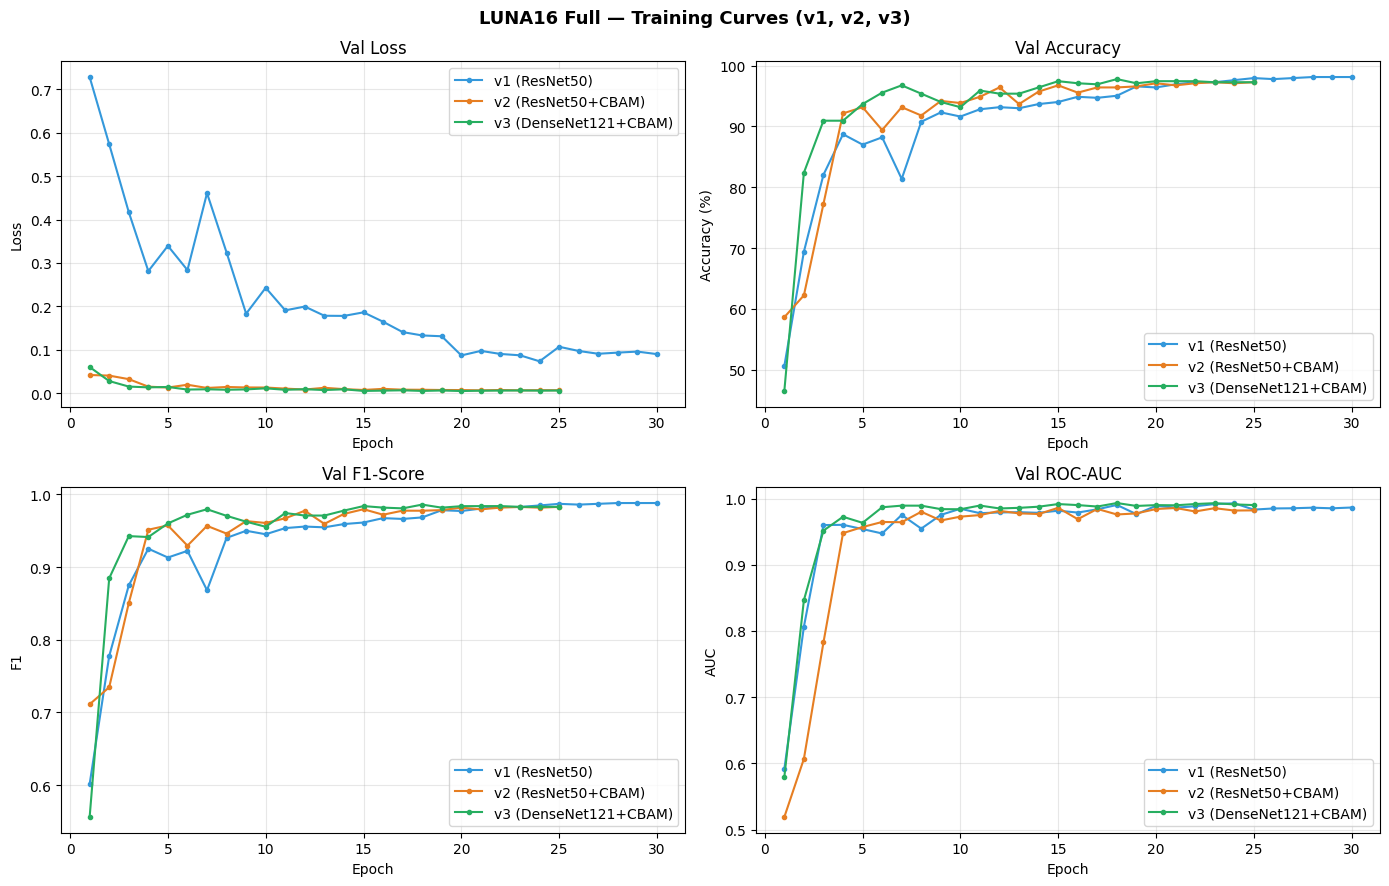


Over/Underfitting Diagnosis (peak train vs peak val):
  v1: peak_train_acc=98.8%  peak_val_acc=98.1%  gap_acc=+0.7%  gap_f1=-0.0005  → Healthy fit
  v2: peak_train_acc=89.6%  peak_val_acc=97.3%  gap_acc=-7.7%  gap_f1=-0.0903  → Healthy — val ≥ train (MixUp signature)
  v3: peak_train_acc=90.7%  peak_val_acc=97.8%  gap_acc=-7.1%  gap_f1=-0.0787  → Healthy — val ≥ train (MixUp signature)


In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("LUNA16 Full — Training Curves (v1, v2, v3)", fontsize=13, fontweight="bold")

for hist, label, color in [(hist_v1, "v1 (ResNet50)", "#3498db"),
                            (hist_v2, "v2 (ResNet50+CBAM)", "#e67e22"),
                            (hist_v3, "v3 (DenseNet121+CBAM)", "#27ae60")]:
    eps = range(1, len(hist["val_loss"])+1)
    ax[0,0].plot(eps, hist["val_loss"], "-o", ms=3, label=label, color=color)
    ax[0,1].plot(eps, [v*100 for v in hist["val_acc"]], "-o", ms=3, label=label, color=color)
    ax[1,0].plot(eps, hist["val_f1"], "-o", ms=3, label=label, color=color)
    ax[1,1].plot(eps, hist["val_auc"], "-o", ms=3, label=label, color=color)

ax[0,0].set(title="Val Loss",     xlabel="Epoch", ylabel="Loss")
ax[0,1].set(title="Val Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
ax[1,0].set(title="Val F1-Score", xlabel="Epoch", ylabel="F1")
ax[1,1].set(title="Val ROC-AUC",  xlabel="Epoch", ylabel="AUC")
for a in ax.ravel():
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Per-version overfitting diagnosis
print("\nOver/Underfitting Diagnosis (peak train vs peak val):")
for hist, name in [(hist_v1, "v1"), (hist_v2, "v2"), (hist_v3, "v3")]:
    pa, pv = max(hist['train_acc'])*100, max(hist['val_acc'])*100
    pf_t, pf_v = max(hist['train_f1']), max(hist['val_f1'])
    gap_a = pa - pv; gap_f = pf_t - pf_v
    if gap_a > 10 or gap_f > 0.08: diag = "WARNING: possible overfitting"
    elif pv < 80: diag = "WARNING: possible underfitting"
    elif gap_a < 0: diag = "Healthy — val ≥ train (MixUp signature)"
    else: diag = "Healthy fit"
    print(f"  {name}: peak_train_acc={pa:.1f}%  peak_val_acc={pv:.1f}%  gap_acc={gap_a:+.1f}%  gap_f1={gap_f:+.4f}  → {diag}")


## 9 · ROC & PR Curves (all 3 versions, TTA where applicable)

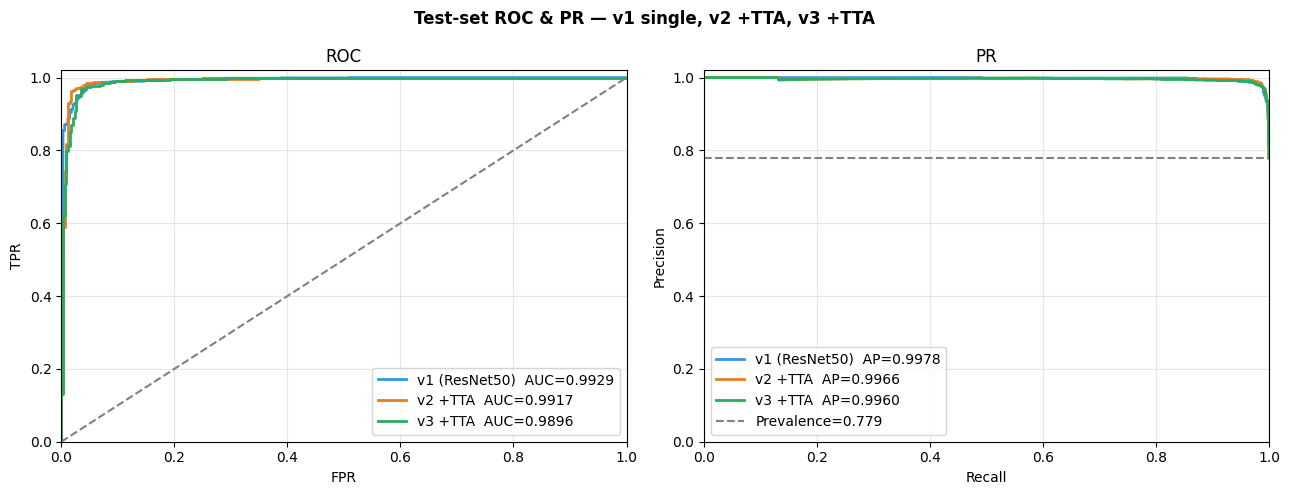

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test-set ROC & PR — v1 single, v2 +TTA, v3 +TTA",
             fontsize=12, fontweight="bold")

for ty, ts, lab, color in [(ty1, ts1, "v1 (ResNet50)", "#3498db"),
                            (ty2_t, ts2_t, "v2 +TTA", "#e67e22"),
                            (ty3_t, ts3_t, "v3 +TTA", "#27ae60")]:
    fpr, tpr, _ = roc_curve(ty, ts)
    auc_v       = roc_auc_score(ty, ts)
    ax[0].plot(fpr, tpr, lw=2, label=f"{lab}  AUC={auc_v:.4f}", color=color)
    p, r, _ = precision_recall_curve(ty, ts)
    ap      = average_precision_score(ty, ts)
    ax[1].plot(r, p, lw=2, label=f"{lab}  AP={ap:.4f}", color=color)

ax[0].plot([0,1],[0,1], "--", color="gray")
ax[0].set(xlim=(0,1), ylim=(0,1.02), xlabel="FPR", ylabel="TPR", title="ROC")
ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)
ax[1].axhline((ty1==1).mean(), color="gray", ls="--",
              label=f"Prevalence={(ty1==1).mean():.3f}")
ax[1].set(xlim=(0,1), ylim=(0,1.02), xlabel="Recall", ylabel="Precision", title="PR")
ax[1].legend(loc="lower left"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10 · Confusion Matrices (all 3 versions)

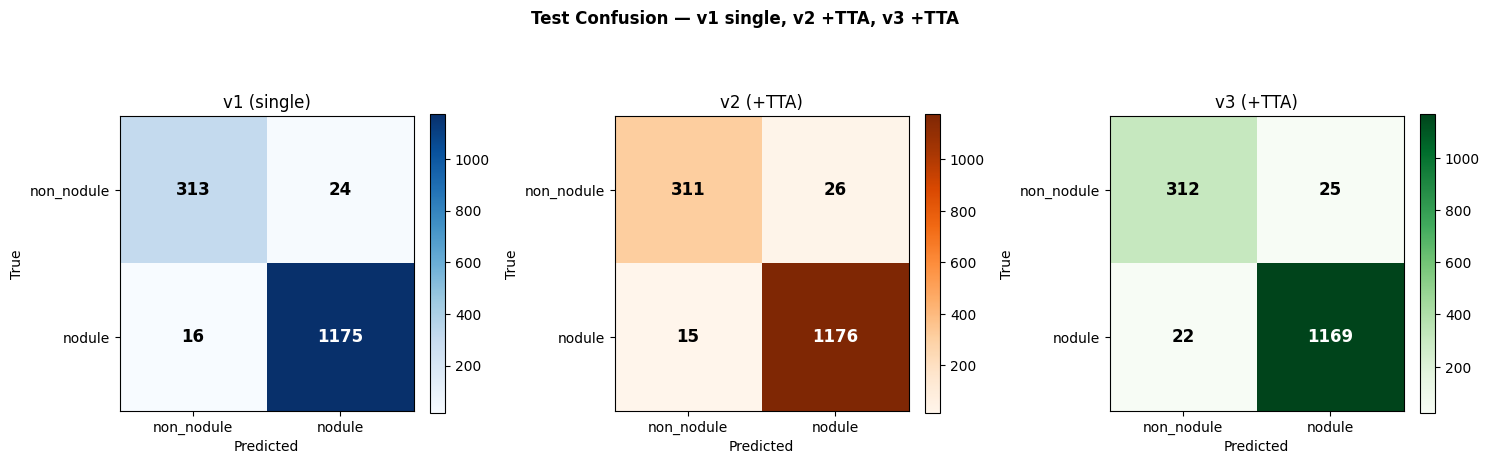

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Test Confusion — v1 single, v2 +TTA, v3 +TTA",
             fontsize=12, fontweight="bold")
for a, m, ttl, cmap in [(ax[0], m_v1,   "v1 (single)",  "Blues"),
                         (ax[1], m_v2_t, "v2 (+TTA)",   "Oranges"),
                         (ax[2], m_v3_t, "v3 (+TTA)",   "Greens")]:
    cm = np.array([[m['confusion']['TN'], m['confusion']['FP']],
                   [m['confusion']['FN'], m['confusion']['TP']]])
    im = a.imshow(cm, cmap=cmap); plt.colorbar(im, ax=a, fraction=0.046)
    a.set(xticks=range(2), yticks=range(2),
          xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
          xlabel="Predicted", ylabel="True", title=ttl)
    th = cm.max()/2
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j]>th else "black", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 11 · Final 3-Way Comparison Table — Test Metrics

In [14]:
rows = ["accuracy","balanced_acc","precision","recall","specificity",
        "f1","mcc","roc_auc","pr_auc"]

print("="*92)
print(f"  {'Metric':<16} {'v1 (single)':>14} {'v2 (+TTA)':>14} {'v3 (+TTA)':>14} "
      f"{'Δ v3-v1':>10} {'Δ v3-v2':>10}")
print("-"*92)
for k in rows:
    a, b, c = m_v1[k], m_v2_t[k], m_v3_t[k]
    da = c - a; db = c - b
    sa = "+" if da>=0 else ""; sb = "+" if db>=0 else ""
    print(f"  {k:<16} {a:>14.4f} {b:>14.4f} {c:>14.4f} {sa}{da:>9.4f} {sb}{db:>9.4f}")
print("="*92)
print(f"\n  Test set: {len(test_ds)} patches across 176 patients (subsets 8+9)")
print(f"  Train set: {len(train_ds)} patches across ~623 patients (subsets 0-6)")
print(f"  CI on F1 ≈ ±0.008 at this test size (vs ±0.012 with prior 662-sample test)")

# Save full 3-way report
report = {
    "split_scheme": {"train": "subsets 0-6", "val": "subset 7", "test": "subsets 8+9"},
    "train_size": len(train_ds), "val_size": len(val_ds), "test_size": len(test_ds),
    "v1_full": {"backbone": "resnet50", "loss": "weighted_CE", "tta": False, "test": m_v1},
    "v2_full": {"backbone": "resnet50_cbam", "loss": "focal", "tta": True,
                "test_single": m_v2_s, "test_tta": m_v2_t},
    "v3_full": {"backbone": "densenet121_cbam", "loss": "focal", "tta": True,
                "test_single": m_v3_s, "test_tta": m_v3_t},
}
(RUNS_DIR/"comparison_report.json").write_text(json.dumps(report, indent=2))
print(f"\nSaved to {RUNS_DIR/'comparison_report.json'}")


  Metric              v1 (single)      v2 (+TTA)      v3 (+TTA)    Δ v3-v1    Δ v3-v2
--------------------------------------------------------------------------------------------
  accuracy                 0.9738         0.9732         0.9692   -0.0046   -0.0039
  balanced_acc             0.9577         0.9551         0.9537   -0.0040   -0.0015
  precision                0.9800         0.9784         0.9791   -0.0009 +   0.0007
  recall                   0.9866         0.9874         0.9815   -0.0050   -0.0059
  specificity              0.9288         0.9228         0.9258   -0.0030 +   0.0030
  f1                       0.9833         0.9829         0.9803   -0.0030   -0.0026
  mcc                      0.9233         0.9212         0.9103   -0.0131   -0.0110
  roc_auc                  0.9929         0.9917         0.9896   -0.0033   -0.0021
  pr_auc                   0.9978         0.9966         0.9960   -0.0018   -0.0006

  Test set: 1528 patches across 176 patients (subsets 8+9)
  T

## 12 · Visual Comparison — Bar Chart of All Metrics

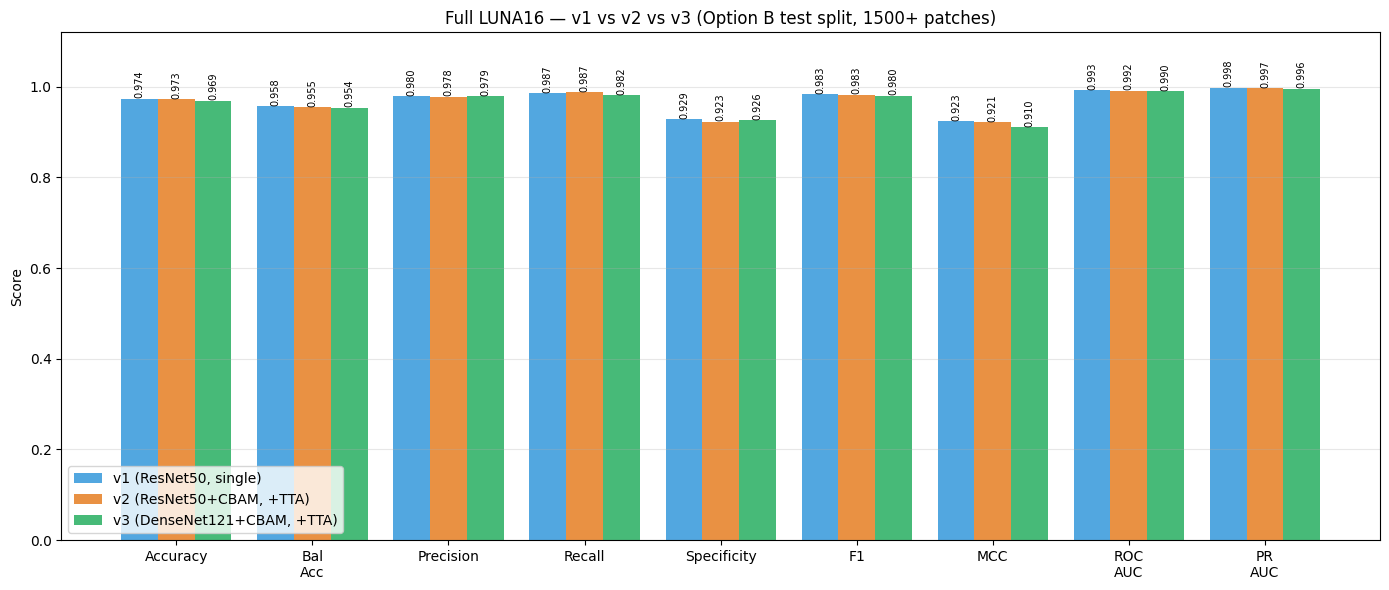

In [15]:
labels = ["Accuracy", "Bal\nAcc", "Precision", "Recall", "Specificity",
          "F1", "MCC", "ROC\nAUC", "PR\nAUC"]
keys   = rows

v1_vals = [m_v1[k]    for k in keys]
v2_vals = [m_v2_t[k]  for k in keys]
v3_vals = [m_v3_t[k]  for k in keys]

x = np.arange(len(keys)); w = 0.27
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, v1_vals, w, label="v1 (ResNet50, single)",         color="#3498db", alpha=0.85)
ax.bar(x,     v2_vals, w, label="v2 (ResNet50+CBAM, +TTA)",      color="#e67e22", alpha=0.85)
ax.bar(x + w, v3_vals, w, label="v3 (DenseNet121+CBAM, +TTA)",   color="#27ae60", alpha=0.85)
for i in range(len(keys)):
    ax.text(x[i]-w, v1_vals[i]+0.005, f"{v1_vals[i]:.3f}", ha="center", fontsize=7, rotation=90)
    ax.text(x[i],   v2_vals[i]+0.005, f"{v2_vals[i]:.3f}", ha="center", fontsize=7, rotation=90)
    ax.text(x[i]+w, v3_vals[i]+0.005, f"{v3_vals[i]:.3f}", ha="center", fontsize=7, rotation=90)
ax.set(ylim=(0, 1.12), ylabel="Score", xticks=x, xticklabels=labels,
       title="Full LUNA16 — v1 vs v2 vs v3 (Option B test split, 1500+ patches)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 13 · Final Summary

In [16]:
print("="*70)
print("  LUNA16 FULL-DATASET 3-WAY COMPARISON — FINAL")
print("="*70)
print(f"  Train: {len(train_ds)} patches  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"  Split: subsets 0-6 → train | 7 → val | 8+9 → test (patient-level)")
print("-"*70)
print(f"  Best test F1:")
print(f"    v1 (ResNet-50, weighted CE)       : {m_v1['f1']:.4f}")
print(f"    v2 (ResNet-50 + CBAM + Focal+MixUp+TTA): {m_v2_t['f1']:.4f}")
print(f"    v3 (DenseNet-121 + CBAM + Focal+MixUp+TTA): {m_v3_t['f1']:.4f}")
print(f"  Best test MCC:")
print(f"    v1: {m_v1['mcc']:.4f}   v2: {m_v2_t['mcc']:.4f}   v3: {m_v3_t['mcc']:.4f}")
print(f"  Best test ROC-AUC:")
print(f"    v1: {m_v1['roc_auc']:.4f}   v2: {m_v2_t['roc_auc']:.4f}   v3: {m_v3_t['roc_auc']:.4f}")
print("="*70)


  LUNA16 FULL-DATASET 3-WAY COMPARISON — FINAL
  Train: 4972 patches  Val: 585  Test: 1528
  Split: subsets 0-6 → train | 7 → val | 8+9 → test (patient-level)
----------------------------------------------------------------------
  Best test F1:
    v1 (ResNet-50, weighted CE)       : 0.9833
    v2 (ResNet-50 + CBAM + Focal+MixUp+TTA): 0.9829
    v3 (DenseNet-121 + CBAM + Focal+MixUp+TTA): 0.9803
  Best test MCC:
    v1: 0.9233   v2: 0.9212   v3: 0.9103
  Best test ROC-AUC:
    v1: 0.9929   v2: 0.9917   v3: 0.9896
